# Proyecto Integrado 2

## Paso 1. Abrir el archivo de datos y leer la información general

In [ ]:
# importar librerias
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)


In [ ]:
# Leer datos y vista previa
data = pd.read_csv('https://code.s3.yandex.net/datasets/logs_exp.csv', sep='\t')
data.head()


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [ ]:
# información
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [ ]:
data.describe()


,DeviceIDHash,EventTimestamp,ExpId
count,2.441260e+05,2.441260e+05,244126.000000
mean,4.627568e+18,1.564914e+09,247.022296
std,2.642425e+18,1.771343e+05,0.824434
min,6.888747e+15,1.564030e+09,246.000000
25%,2.372212e+18,1.564757e+09,246.000000
50%,4.623192e+18,1.564919e+09,247.000000
75%,6.932517e+18,1.565075e+09,248.000000
max,9.222603e+18,1.565213e+09,248.000000


 Everything's great. We don't have missing values. Data types match our expectations. We can clearly see that we have all three experiments: 246, 247, 248

# Paso 2. Preparar los datos para el análisis
 + Cambia el nombre de las columnas de manera que sea conveniente para ti

In [5]:
# %%
data.rename(columns={
    'EventName': 'event',
    'DeviceIDHash': 'user',
    'EventTimestamp': 'timestamp',
    'ExpId': 'exp_id',
}, inplace=True)
data.head()


,event,user,timestamp,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


 + Comprueba si hay tipos de datos y valores ausentes. Corrige los datos si es necesario

 As we've already seen, everything's OK

 + Agrega una columna de fecha y hora y una columna separada para las fechas

In [6]:
# %%
data['date_time'] = pd.to_datetime(data['timestamp'], unit='s')
data['date'] = data['date_time'].dt.floor('1D')
data.head()


,event,user,timestamp,exp_id,date_time,date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


# Step 3. Estudiar y Comprobar los Datos

- ¿Cuántos eventos hay en los registros?

- ¿Cuántos usuarios y usuarias hay en los registros?

- ¿Cuál es el promedio de eventos por usuario?


In [7]:
# %%
events = len(data)
users = len(data['user'].unique())
events_per_user = events / users
print(f'{events} events')
print(f'{users} users')
print(f'{events_per_user} events_per_user')


244126 events
7551 users
32.33028737915508 events_per_user


### ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima. Traza un histograma por fecha y hora. ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? Los eventos más antiguos podrían terminar en los registros de algunos usuarios o usuarias por razones técnicas y esto podría sesgar el panorama general. Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior. ¿Qué periodo representan realmente los datos?

In [8]:
# fecha máxima y mínima
print(data['date_time'].min(), data['date_time'].max())


2019-07-25 04:43:36 2019-08-07 21:15:17


<Axes: >

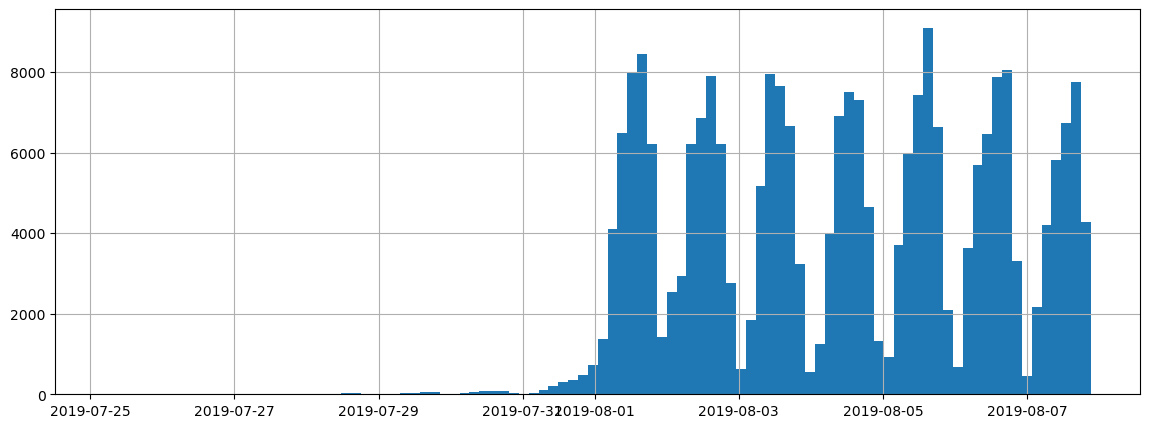

In [9]:
# Trazar histograma por fecha y hora
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
data['date_time'].hist(bins=100, figsize=(14, 5))


<Axes: xlabel='date'>

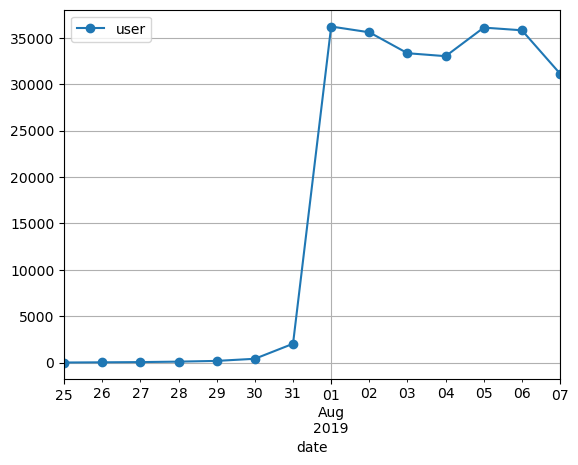

In [10]:
# Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior
data.pivot_table(index='date', values='user', aggfunc='count').plot(style='o-', grid=True)


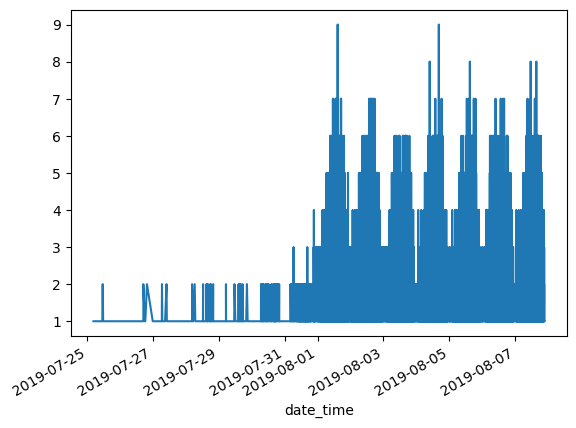

,event,user,timestamp,exp_id,date_time,date
1990,MainScreenAppear,7701922487875823903,1564606857,247,2019-07-31 21:00:57,2019-07-31
1991,MainScreenAppear,2539077412200498909,1564606905,247,2019-07-31 21:01:45,2019-07-31
1992,OffersScreenAppear,3286987355161301427,1564606941,248,2019-07-31 21:02:21,2019-07-31
1993,OffersScreenAppear,3187166762535343300,1564606943,247,2019-07-31 21:02:23,2019-07-31
1994,MainScreenAppear,1118952406011435924,1564607005,248,2019-07-31 21:03:25,2019-07-31


In [11]:
data.groupby("date_time")["user"].count().plot()
plt.show()


data.query('date_time > "2019-07-31 21:00"', inplace=True)
data.head()


<Axes: >

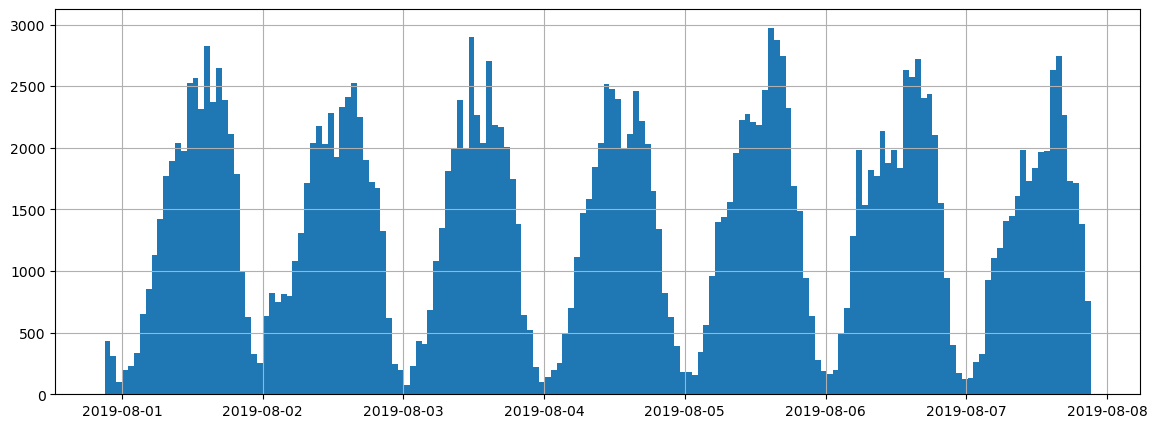

In [12]:
# ¿Qué periodo representan realmente los datos?
data['date_time'].hist(bins=7*24, figsize=(14, 5))


 Tenemos los datos para la semana de 2019-08-01 a 2019-08-07 (con un turno de tres horas).

 Los estudiantes no se darán cuenta de un cambio tan pequeño, por lo que dudo que debamos centrarnos en eso.

### ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [13]:
# %%
events = len(data)
users = len(data['user'].unique())
events_per_user = events / users
print(f'{events} events')
print(f'{users} users')
print(f'{events_per_user} events_per_user')


242136 events
7538 users
32.12204828867073 events_per_user


 We lost less than 1%.

### Asegúrate de tener usuarios y usuarias de los tres grupos experimentales.

In [14]:
# %%
data['exp_id'].value_counts()


exp_id
248    85039
246    79679
247    77418
Name: count, dtype: int64

# Paso 4. Estudiar el embudo de eventos

### Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

In [15]:
# %%
data.pivot_table(index='event', values='user', aggfunc='count').sort_values('user', ascending=False)


,user
event,
MainScreenAppear,117992
OffersScreenAppear,46548
CartScreenAppear,42406
PaymentScreenSuccessful,34146
Tutorial,1044


### Encuentra la cantidad de usuarios y usuarias que realizaron cada una de estas acciones. Ordena los eventos por el número de usuarios y usuarias. Calcula la proporción de usuarios y usuarias que realizaron la acción al menos una vez.

In [16]:
# Ordena los eventos por el número de usuarios y usuarias
users_per_event = (
    data
    .pivot_table(index='event', values='user', aggfunc=lambda x: x.nunique())
    .sort_values('user', ascending=False)
)
users_per_event


,user
event,
MainScreenAppear,7423
OffersScreenAppear,4597
CartScreenAppear,3736
PaymentScreenSuccessful,3540
Tutorial,843


In [17]:
# Calcula la proporción de usuarios y usuarias que realizaron la acción al menos una vez.
users_per_event / len(data['user'].unique())


,user
event,
MainScreenAppear,0.984744
OffersScreenAppear,0.609843
CartScreenAppear,0.495622
PaymentScreenSuccessful,0.469621
Tutorial,0.111833


### ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

 Vamos a tomar todos los datos en orden decreciente de frecuencia, excepto Tutorial

### Utiliza el embudo de eventos para encontrar la proporción de usuarios y usuarias que pasan de una etapa a la siguiente. (Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B).

In [18]:
# %%
users_funnel = users_per_event[:-1]
users_funnel = (users_funnel / users_funnel.shift())[1:]
users_funnel


,user
event,
OffersScreenAppear,0.619291
CartScreenAppear,0.812704
PaymentScreenSuccessful,0.947537


### ¿En qué etapa pierdes más usuarios y usuarias?

La disminución más importante se observa en la primera fase, al pasar de MainScreenAppear a OffersScreenAppear. Probablemente la mecánica debería ser mejorada para que los usuarios pasaran a OffersScreen.

### ¿Qué porcentaje de usuarios y usuarias hace todo el viaje desde su primer evento hasta el pago?

In [19]:
# %%
print('{} make it from the main screen to successful payment'
      .format((users_per_event.loc['PaymentScreenSuccessful'] / users_per_event.loc['MainScreenAppear'])['user']))


0.47689613363869054 make it from the main screen to successful payment


# Paso 5. Estudiar los resultados del experimento

### ¿Cuántos usuarios y usuarias hay en cada grupo?

In [20]:
# %%
users_per_group = data.pivot_table(index='exp_id', values='user', aggfunc=lambda x: x.nunique())['user']
users_per_group


exp_id
246    2484
247    2517
248    2537
Name: user, dtype: int64

### Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247. 

In [21]:
# hay una diferencia estadísticamente significativa entre las muestras 246 y 247.
#data.pivot_table(index='event', values='user', columns='exp_id', aggfunc=lambda x: x.nunique())
users_events_per_group = data.pivot_table(index='event', values='user', columns='exp_id', aggfunc='nunique')
users_events_per_group


#sin pivot_table
#data.groupby(['event', 'exp_id'])['user'].nunique().unstack()

exp_id,246,247,248
event,,,
CartScreenAppear,1266,1239,1231
MainScreenAppear,2450,2479,2494
OffersScreenAppear,1542,1524,1531
PaymentScreenSuccessful,1200,1158,1182
Tutorial,278,284,281


**Prueba chi cuadrada**

Se evalua si las diferencias en los **conteos** entre los grupos 246 y 247, para cada evento, pueden deberse al azar o si son estadísticamente significativas (diferencia global, no por evento).

In [ ]:
#Prueba chi cuadrada
from scipy.stats import chi2_contingency

# Filtrar solo las columnas 246 y 247
contingency_table = users_events_per_group[[246, 247]]

# Prueba chi-cuadrado
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Estadístico chi²: {chi2_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

if p_value < 0.05:
    print("✅ Hay una diferencia estadísticamente significativa en las frecuencias entre los grupos 246 y 247.")
else:
    print("❌ No hay una diferencia estadísticamente significativa en las frecuencias entre los grupos 246 y 247.")



Estadístico chi²: 1.1780
Valor p: 0.8817
❌ No hay una diferencia estadísticamente significativa en las frecuencias entre los grupos 246 y 247.


### Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios y usuarias que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?

### Z test 
Se aplica un Z test para comparar las proporciones entre dos grupos, no solo conteos absolutos. 

In [ ]:
# comparar 1 solo evento
from statsmodels.stats.proportion import proportions_ztest

# evento 'CartScreenAppear':
successes = [1266, 1239]  # usuarios en el evento en grupo 246 y 247
n_obs = [users_per_group.loc[246], users_per_group.loc[247]]  # total de usuarios en cada grupo

z_stat, p_value = proportions_ztest(successes, n_obs)

print(f'Estadístico Z: {z_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

if p_value < 0.05:
    print("✅ Diferencia estadísticamente significativa en proporciones.")
else:
    print("❌ No hay diferencia significativa en proporciones.")

Estadístico Z: 1.2311
Valor p: 0.2183
❌ No hay diferencia significativa en proporciones.


In [26]:
# %%
from scipy import stats
import numpy as np
import math

def check_hypothesis(successes1, successes2, trials1, trials2, alpha=0.01):
    # proportion of successes in the first group:
    p1 = successes1/trials1

    # proportion of successes in the second group:
    p2 = successes2/trials2

    # proportion of successes in the combined dataset:
    p_combined = (successes1 + successes2) / (trials1 + trials2)

    # the difference of proportions in datasets
    difference = p1 - p2
    
    # Cálculo de la estadística en desviaciones estándar de la distribución normal
    z_value = difference / math.sqrt(p_combined * (1 - p_combined) * (1/trials1 + 1/trials2))

    # setting standard normal distribution (mean= 0, standard deviation=1)
    distr = stats.norm(0, 1) 

    p_value = (1 - distr.cdf(abs(z_value))) * 2

    print('p-value: ', p_value)

    if (p_value < alpha):
        print("Rejecting the null hypothesis: there is a significant difference between the proportions")
    else:
        print("Failed to reject the null hypothesis, there is no reason to consider the proportions different")  


In [ ]:
# %%
check_hypothesis(users_events_per_group.loc['MainScreenAppear', 246],
                 users_events_per_group.loc['MainScreenAppear', 247],
                 users_per_group.loc[246],
                 users_per_group.loc[247],
                )                 


p-value:  0.6756217702005545
Failed to reject the null hypothesis, there is no reason to consider the proportions different


In [ ]:
# %%
def check_event_hypithesis(users_events_per_group, users_per_group,
                           event,
                           exp1, exp2
                          ):
    frac1 = users_events_per_group.loc[event, exp1] / users_per_group.loc[exp1]
    frac2 = users_events_per_group.loc[event, exp2] / users_per_group.loc[exp2]
    print(f'{frac1} with {event} event in group {exp1}')
    print(f'{frac2} with {event} event in group {exp2}')
    check_hypothesis(users_events_per_group.loc[event, exp1],
                     users_events_per_group.loc[event, exp2],
                     users_per_group.loc[exp1],
                     users_per_group.loc[exp2],
                    )


In [ ]:
# %%
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group, users_per_group,
                          event, 246, 247)
    print()


0.5096618357487923 with CartScreenAppear event in group 246
0.4922526817640048 with CartScreenAppear event in group 247
p-value:  0.2182812140633792
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9863123993558777 with MainScreenAppear event in group 246
0.9849026618990863 with MainScreenAppear event in group 247
p-value:  0.6756217702005545
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6207729468599034 with OffersScreenAppear event in group 246
0.6054827175208581 with OffersScreenAppear event in group 247
p-value:  0.26698769175859516
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.4830917874396135 with PaymentScreenSuccessful event in group 246
0.4600715137067938 with PaymentScreenSuccessful event in group 247
p-value:  0.10298394982948822
Failed to reject the null hypothesis, there is no reason to consider the proportions different



 Podemos afirmar con un alto grado de confianza que los resultados en los grupos de control son iguales. Es decir, la división en grupos y los cálculos parecen ser correctos.

### Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?

In [ ]:
# %%
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group, users_per_group,
                          event, 246, 248)
    print()


0.5096618357487923 with CartScreenAppear event in group 246
0.48521876231769806 with CartScreenAppear event in group 248
p-value:  0.08328412977507749
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9863123993558777 with MainScreenAppear event in group 246
0.9830508474576272 with MainScreenAppear event in group 248
p-value:  0.34705881021236484
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6207729468599034 with OffersScreenAppear event in group 246
0.6034686637761135 with OffersScreenAppear event in group 248
p-value:  0.20836205402738917
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.4830917874396135 with PaymentScreenSuccessful event in group 246
0.4659046117461569 with PaymentScreenSuccessful event in group 248
p-value:  0.22269358994682742
Failed to reject the null hypothesis, there is no reason to consider the proportions differen

 Tampoco podemos ver aquí ninguna gran diferencia. Aunque la proporción de eventos por usuario ha disminuido, las diferencias siguen siendo estadísticamente insignificantes.

In [ ]:
# %%
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group, users_per_group,
                          event, 247, 248)
    print()


0.4922526817640048 with CartScreenAppear event in group 247
0.48521876231769806 with CartScreenAppear event in group 248
p-value:  0.6169517476996997
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9849026618990863 with MainScreenAppear event in group 247
0.9830508474576272 with MainScreenAppear event in group 248
p-value:  0.6001661582453706
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6054827175208581 with OffersScreenAppear event in group 247
0.6034686637761135 with OffersScreenAppear event in group 248
p-value:  0.8835956656016957
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.4600715137067938 with PaymentScreenSuccessful event in group 247
0.4659046117461569 with PaymentScreenSuccessful event in group 248
p-value:  0.6775413642906454
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0

En este caso, todos los acontecimientos, excepto el pago, crecieron menos en número, pero todas las diferencias son realmente pequeñas.

In [ ]:
# %%
users_events_per_group_control = users_events_per_group.copy()
users_events_per_group_control.loc[:, 247] += users_events_per_group_control.loc[:, 246]
users_events_per_group_control.drop(columns=246, inplace=True)
users_events_per_group_control


exp_id,247,248
event,,
CartScreenAppear,2505,1231
MainScreenAppear,4929,2494
OffersScreenAppear,3066,1531
PaymentScreenSuccessful,2358,1182
Tutorial,562,281


In [ ]:
# %%
users_per_group_control = users_per_group.copy()
users_per_group_control.loc[247] += users_per_group_control.loc[246]
users_per_group_control.drop(246, inplace=True)
users_per_group_control


exp_id
247    5001
248    2537
Name: user, dtype: int64

In [ ]:
# %%
for event in users_events_per_group.index:
    check_event_hypithesis(users_events_per_group_control, users_per_group_control,
                          event, 247, 248)
    print()


0.5008998200359928 with CartScreenAppear event in group 247
0.48521876231769806 with CartScreenAppear event in group 248
p-value:  0.19819340844527744
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.9856028794241152 with MainScreenAppear event in group 247
0.9830508474576272 with MainScreenAppear event in group 248
p-value:  0.39298914928006035
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.6130773845230953 with OffersScreenAppear event in group 247
0.6034686637761135 with OffersScreenAppear event in group 248
p-value:  0.418998284007599
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0.471505698860228 with PaymentScreenSuccessful event in group 247
0.4659046117461569 with PaymentScreenSuccessful event in group 248
p-value:  0.6452057673098244
Failed to reject the null hypothesis, there is no reason to consider the proportions different

0

Aunque todas las proporciones han disminuido, las diferencias están lejos de ser significativas desde el punto de vista estadístico.